# Free-Generation Evaluation — Results Visualization

Evaluates model-generated free-text answers using a DeBERTa-v3-base classifier trained to distinguish
authentic (ground-truth) answers from model-generated imitations.

**Scoring verdicts per question:**
- **D** (Detected) — answer flagged as imitation → incorrect
- **U** (Undecided) — answer passes as authentic → counted as correct

**Aggregate metrics:**
- `detection_rate` — fraction of answers flagged as imitation (lower = better)
- `indistinguishable_rate` — `(1 − detection_rate) / 0.5` (higher = better)
- `manual_accuracy` — accuracy from human review of undecided items (GPT models only)
- `estimated_overall_accuracy` — combined score; for Qwen models equals `indistinguishable_rate × 0.5`

> **Note on per-question breakdown:** D/U per question is used to compute per-category accuracy.
> For Qwen models (manual_accuracy=0) this equals the true estimate.
> For GPT models the per-question D/U score is the DeBERTa-only pass rate
> (underestimates true accuracy because manual review of undecided items is not reflected per-question).

**Conditions:**
- **A — Full Metadata:** correct title, author, date, genre in prompt
- **C — Shuffled Metadata:** metadata present but randomly permuted (wrong book info)

**Models:**
| Label | Fine-tuning | Condition | Benchmark |
|---|---|---|---|
| GPT-5.4 | None | A | v0.1 |
| GPT-4.1 | None | A | v0.1 |
| Metadata FT run2 | QLoRA on HathiTrust metadata passages | A, C | v0.2 |
| Domain FT run1 | QLoRA on 100 Gutenberg historical books | A, C | v0.2 |

---
## 1 — Setup & Data Loading

In [4]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', font_scale=1.05)

# ── Paths ────────────────────────────────────────────────────────────────────
SCORES_DIR  = Path('../../bertclassify/scores')
BENCH_V01   = Path('../../booksample/chronologic_en_0.1.jsonl')
BENCH_V02   = Path('../../booksample/chronologic_en_0.2.jsonl')

# ── Score file registry ───────────────────────────────────────────────────────
# (display_name, filename, condition, group, benchmark_version)
SCORE_FILES = [
    ('GPT-5.4',          'free_gen_gpt-5.4_20260318_180622_score.json', 'A', 'GPT baseline', 'v0.1'),
    ('GPT-4.1',          'free_gen_gpt4.1_score.json',                  'A', 'GPT baseline', 'v0.1'),
    ('Metadata FT run2', 'free_gen_qwen7b_metaft_run2_condA_score.json', 'A', 'Metadata FT', 'v0.2'),
    ('Metadata FT run2', 'free_gen_qwen7b_metaft_run2_condC_score.json', 'C', 'Metadata FT', 'v0.2'),
    ('Domain FT run1',   'free_gen_qwen7b_domainft_run1_condA_score.json', 'A', 'Domain FT', 'v0.2'),
    ('Domain FT run1',   'free_gen_qwen7b_domainft_run1_condC_score.json', 'C', 'Domain FT', 'v0.2'),
]

# ── Load benchmark metadata ──────────────────────────────────────────────────
def load_benchmark(path):
    bench = {}
    with open(path, encoding='utf-8') as f:
        for line in f:
            if not line.strip(): continue
            q = json.loads(line)
            bench[str(q['question_number'])] = q
    return bench

bench_v01 = load_benchmark(BENCH_V01)
bench_v02 = load_benchmark(BENCH_V02)
print(f'Benchmark v0.1: {len(bench_v01)} questions')
print(f'Benchmark v0.2: {len(bench_v02)} questions')

Benchmark v0.1: 709 questions
Benchmark v0.2: 714 questions


In [5]:
# ── Build overall metrics dataframe ──────────────────────────────────────────
overall_rows = []
score_data   = {}  # key: (model, condition) → raw score dict

for name, fname, cond, group, bver in SCORE_FILES:
    path = SCORES_DIR / fname
    with open(path) as f:
        d = json.load(f)
    key = (name, cond)
    score_data[key] = d

    scored = d['scored_answers']
    n_total     = len(scored)
    n_detected  = sum(1 for v in scored.values() if v == 'D')
    n_undecided = sum(1 for v in scored.values() if v == 'U')

    overall_rows.append({
        'model':     name,
        'condition': cond,
        'group':     group,
        'bench_ver': bver,
        'n_total':   n_total,
        'n_detected':  n_detected,
        'n_undecided': n_undecided,
        'detection_rate':             d['detection_rate'],
        'indistinguishable_rate':     d['indistinguishable_rate'],
        'manual_accuracy':            d['manual_accuracy'],
        'estimated_overall_accuracy': d['estimated_overall_accuracy'],
    })

df_overall = pd.DataFrame(overall_rows)
print(f'\nLoaded {len(df_overall)} model/condition entries:')
print(df_overall[['model','condition','group','n_total']].to_string(index=False))


Loaded 6 model/condition entries:
           model condition        group  n_total
         GPT-5.4         A GPT baseline      709
         GPT-4.1         A GPT baseline      709
Metadata FT run2         A  Metadata FT      513
Metadata FT run2         C  Metadata FT      516
  Domain FT run1         A    Domain FT      509
  Domain FT run1         C    Domain FT      511


In [6]:
# ── Build per-question long dataframe ────────────────────────────────────────
# score_q = 1 if verdict == 'U' (passes as authentic), 0 if 'D' (detected)
per_q_rows = []

bench_map = {'v0.1': bench_v01, 'v0.2': bench_v02}

for name, fname, cond, group, bver in SCORE_FILES:
    d     = score_data[(name, cond)]
    bench = bench_map[bver]
    for qnum, verdict in d['scored_answers'].items():
        meta = bench.get(str(qnum), {})
        per_q_rows.append({
            'model':          name,
            'condition':      cond,
            'group':          group,
            'bench_ver':      bver,
            'question_number': int(qnum),
            'verdict':        verdict,
            'score_q':        1 if verdict == 'U' else 0,
            'reasoning_type': meta.get('reasoning_type', 'unknown'),
            'frame_type':     meta.get('frame_type',     'unknown'),
        })

df_q = pd.DataFrame(per_q_rows)
print(f'Per-question rows: {len(df_q):,}')
print(f'Reasoning types: {sorted(df_q["reasoning_type"].unique())}')
print(f'Frame types:     {sorted(df_q["frame_type"].unique())}')

Per-question rows: 3,467
Reasoning types: ['abstention', 'character_modeling', 'constrained_generation', 'inference', 'knowledge', 'phrase_cloze', 'sentence_cloze', 'topic_sentence']
Frame types:     ['book_context', 'passage_context', 'world_context']


In [7]:
# ── Colour / style constants ──────────────────────────────────────────────────
GROUP_COLORS = {
    'GPT baseline': '#1565C0',
    'Metadata FT':  '#E65100',
    'Domain FT':    '#2E7D32',
}
COND_COLORS  = {'A': '#2196F3', 'C': '#FF9800'}
COND_LABELS  = {'A': 'A — Correct Meta', 'C': 'C — Shuffled Meta'}
COND_HATCH   = {'A': '',    'C': '///'}

MODEL_ORDER  = ['GPT-5.4', 'GPT-4.1', 'Metadata FT run2', 'Domain FT run1']
MODEL_COLORS = {
    'GPT-5.4':          '#0D47A1',
    'GPT-4.1':          '#1565C0',
    'Metadata FT run2': '#E65100',
    'Domain FT run1':   '#2E7D32',
}

def label(model, cond):
    return f'{model}\n(Cond {cond})'

print('Constants loaded.')

Constants loaded.


---
## 2 — Overall Performance Summary

In [8]:
# ── Summary table ─────────────────────────────────────────────────────────────
disp_cols = ['model','condition','group','bench_ver','n_total',
             'detection_rate','indistinguishable_rate',
             'manual_accuracy','estimated_overall_accuracy']
fmt = {c: '{:.4f}' for c in
       ['detection_rate','indistinguishable_rate','manual_accuracy','estimated_overall_accuracy']}

print('=== Free-Generation Evaluation — Overall Results ===')
display(
    df_overall[disp_cols].style
    .format(fmt)
    .background_gradient(cmap='RdYlGn_r', subset=['detection_rate'], axis=None)
    .background_gradient(cmap='RdYlGn',
        subset=['indistinguishable_rate','manual_accuracy','estimated_overall_accuracy'], axis=None)
    .set_caption('detection_rate: lower is better.  All other metrics: higher is better.')
)

=== Free-Generation Evaluation — Overall Results ===


,model,condition,group,bench_ver,n_total,detection_rate,indistinguishable_rate,manual_accuracy,estimated_overall_accuracy
0,GPT-5.4,A,GPT baseline,v0.1,709,0.7286,0.5428,0.8391,0.6389
1,GPT-4.1,A,GPT baseline,v0.1,709,0.9538,0.0924,0.6588,0.2609
2,Metadata FT run2,A,Metadata FT,v0.2,513,0.9981,0.0039,0.0000,0.0028
3,Metadata FT run2,C,Metadata FT,v0.2,516,0.9942,0.0116,0.0000,0.0084
4,Domain FT run1,A,Domain FT,v0.2,509,0.7741,0.4519,0.0000,0.3221
5,Domain FT run1,C,Domain FT,v0.2,511,0.7515,0.4971,0.0000,0.3557


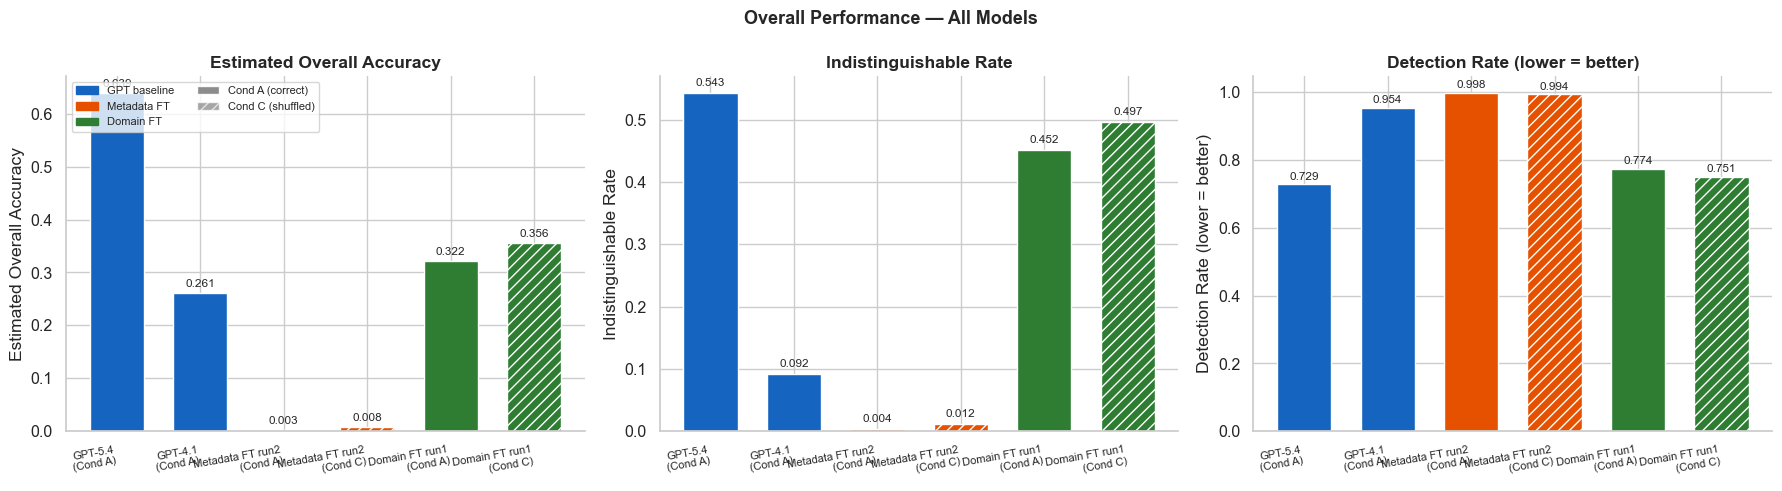

In [9]:
# ── Grouped bar: three key metrics side-by-side ───────────────────────────────
metrics = [
    ('estimated_overall_accuracy', 'Estimated Overall Accuracy',   False),
    ('indistinguishable_rate',     'Indistinguishable Rate',        False),
    ('detection_rate',             'Detection Rate (lower = better)', True),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (col, ylabel, reverse) in zip(axes, metrics):
    labs, vals, colors, hatches = [], [], [], []
    for _, row in df_overall.iterrows():
        labs.append(label(row['model'], row['condition']))
        vals.append(row[col])
        colors.append(GROUP_COLORS[row['group']])
        hatches.append(COND_HATCH[row['condition']])

    x = np.arange(len(labs))
    bars = ax.bar(x, vals, color=colors, edgecolor='white', width=0.65)
    for bar, h in zip(bars, hatches):
        bar.set_hatch(h)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.008, f'{v:.3f}',
                ha='center', va='bottom', fontsize=8.5)

    ax.set_xticks(x)
    ax.set_xticklabels(labs, fontsize=8, rotation=10, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)

# Shared legend
handles = (
    [mpatches.Patch(color=c, label=g) for g, c in GROUP_COLORS.items()] +
    [mpatches.Patch(facecolor='grey', label='Cond A (correct)', alpha=0.9),
     mpatches.Patch(facecolor='grey', hatch='///', label='Cond C (shuffled)', alpha=0.7)]
)
axes[0].legend(handles=handles, fontsize=8, loc='upper left', ncol=2)
plt.suptitle('Overall Performance — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# ── Pivot table: estimated accuracy condA vs condC ────────────────────────────
pivot_oa = df_overall.pivot_table(
    index=['model','group'], columns='condition',
    values='estimated_overall_accuracy'
).round(4)
print('=== Estimated Overall Accuracy — condA vs condC ===')
display(pivot_oa.style
    .format('{:.4f}', na_rep='—')
    .background_gradient(cmap='RdYlGn', axis=None)
)

=== Estimated Overall Accuracy — condA vs condC ===


,condition,A,C
model,group,,
Domain FT run1,Domain FT,0.3221,0.3557
GPT-4.1,GPT baseline,0.2609,—
GPT-5.4,GPT baseline,0.6389,—
Metadata FT run2,Metadata FT,0.0028,0.0084


---
## 3 — Frame Type Analysis
Questions grouped by how context is framed: `book_context`, `passage_context`, or `world_context`.

> Per-question D/U scores joined with benchmark metadata.

In [11]:
# ── Accuracy by frame_type ────────────────────────────────────────────────────
ft_acc = (
    df_q.groupby(['model','condition','group','frame_type'])['score_q']
    .agg(accuracy='mean', n='count')
    .reset_index()
)

# Summary table
ft_table = ft_acc.pivot_table(
    index=['model','condition'], columns='frame_type', values='accuracy'
).round(4)
print('=== Indistinguishable Rate by Frame Type ===')
display(ft_table.style
    .format('{:.4f}', na_rep='—')
    .background_gradient(cmap='RdYlGn', axis=None)
)

=== Indistinguishable Rate by Frame Type ===


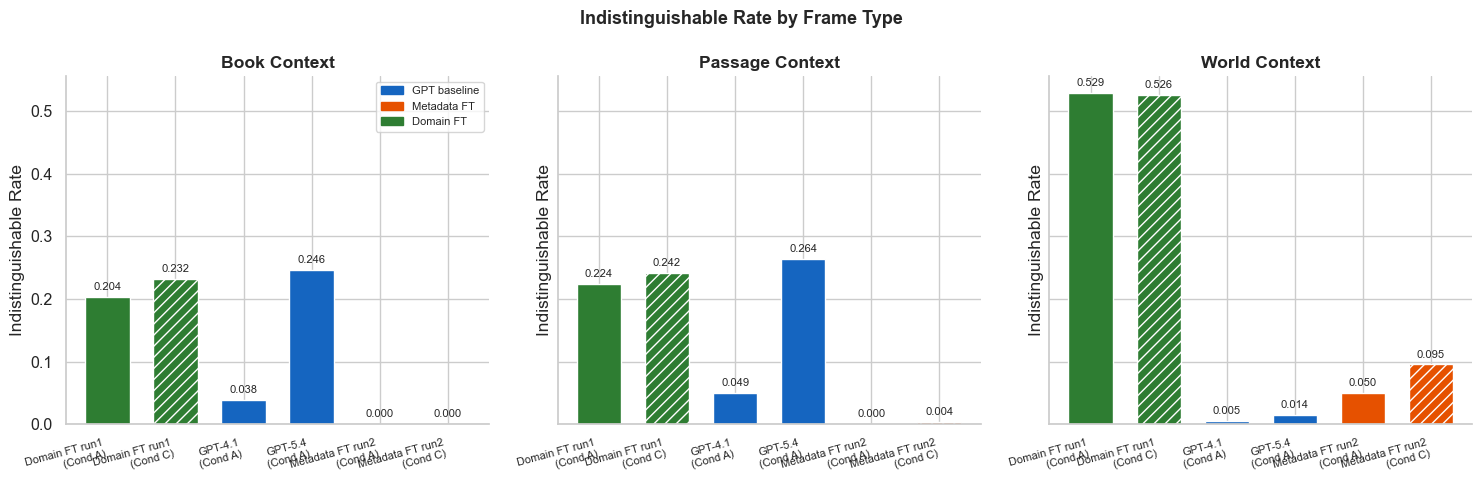

In [12]:
# ── Grouped bars per frame type ───────────────────────────────────────────────
frame_types = sorted(ft_acc['frame_type'].unique())
fig, axes = plt.subplots(1, len(frame_types), figsize=(5*len(frame_types), 5), sharey=True)
if len(frame_types) == 1:
    axes = [axes]

for ax, ft in zip(axes, frame_types):
    sub = ft_acc[ft_acc['frame_type'] == ft].copy()
    sub['label'] = [label(r['model'], r['condition']) for _, r in sub.iterrows()]
    x = np.arange(len(sub))
    colors  = [GROUP_COLORS[r['group']]    for _, r in sub.iterrows()]
    hatches = [COND_HATCH[r['condition']]  for _, r in sub.iterrows()]
    bars = ax.bar(x, sub['accuracy'], color=colors, edgecolor='white', width=0.65)
    for bar, h in zip(bars, hatches):
        bar.set_hatch(h)
    for bar, v in zip(bars, sub['accuracy']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(sub['label'], rotation=15, ha='right', fontsize=8)
    ax.set_title(ft.replace('_',' ').title(), fontweight='bold')
    ax.set_ylabel('Indistinguishable Rate')
    ax.spines[['top','right']].set_visible(False)

handles = [mpatches.Patch(color=c, label=g) for g, c in GROUP_COLORS.items()]
axes[0].legend(handles=handles, fontsize=8)
plt.suptitle('Indistinguishable Rate by Frame Type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\shubh\AppData\Local\Temp\ipykernel_2884\1181565473.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8)
C:\Users\shubh\AppData\Local\Temp\ipykernel_2884\1181565473.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8)
C:\Users\shubh\AppData\Local\Temp\ipykernel_2884\1181565473.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8)
C:\Users\shubh\AppData\Local\Temp\ipykernel_2884\1181565473.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or us

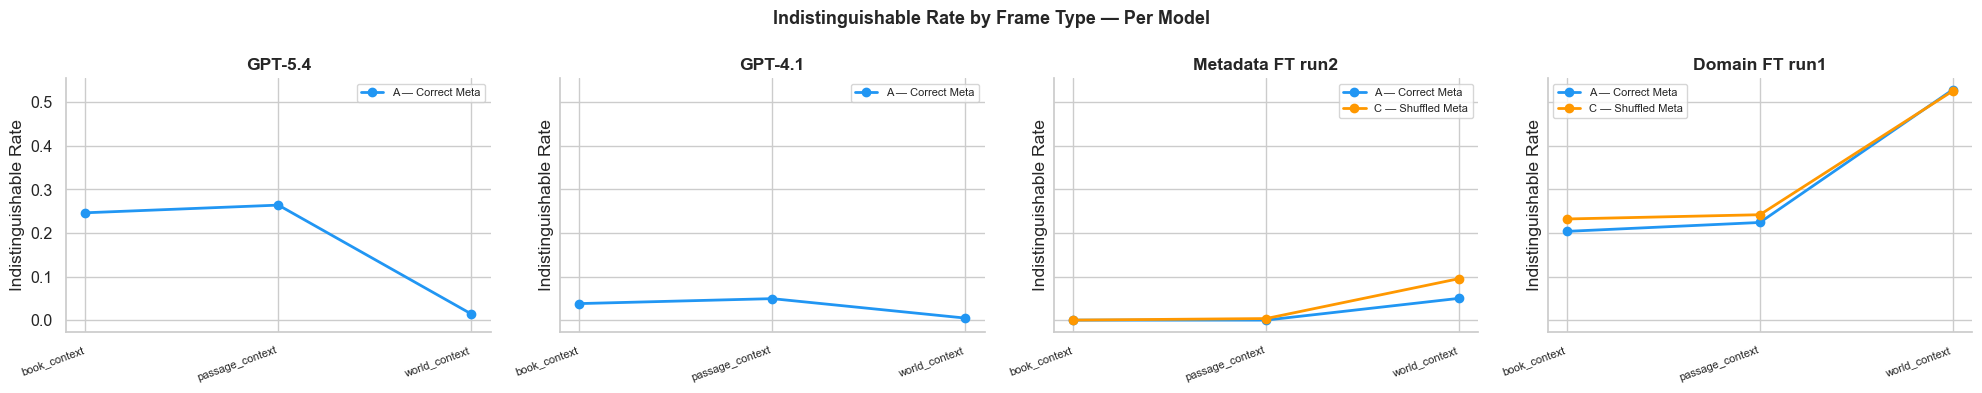

In [13]:
# ── Per-model line plot across frame types ────────────────────────────────────
fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(5*len(MODEL_ORDER), 4), sharey=True)

for ax, model in zip(axes, MODEL_ORDER):
    sub = ft_acc[ft_acc['model'] == model]
    if sub.empty:
        ax.set_visible(False)
        continue
    for cond in sub['condition'].unique():
        d = sub[sub['condition'] == cond].set_index('frame_type')['accuracy']
        ax.plot(d.index, d.values, marker='o',
                color=COND_COLORS.get(cond, 'grey'),
                label=COND_LABELS.get(cond, cond), linewidth=2)
    ax.set_title(model, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8)
    ax.set_ylabel('Indistinguishable Rate')
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Indistinguishable Rate by Frame Type — Per Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

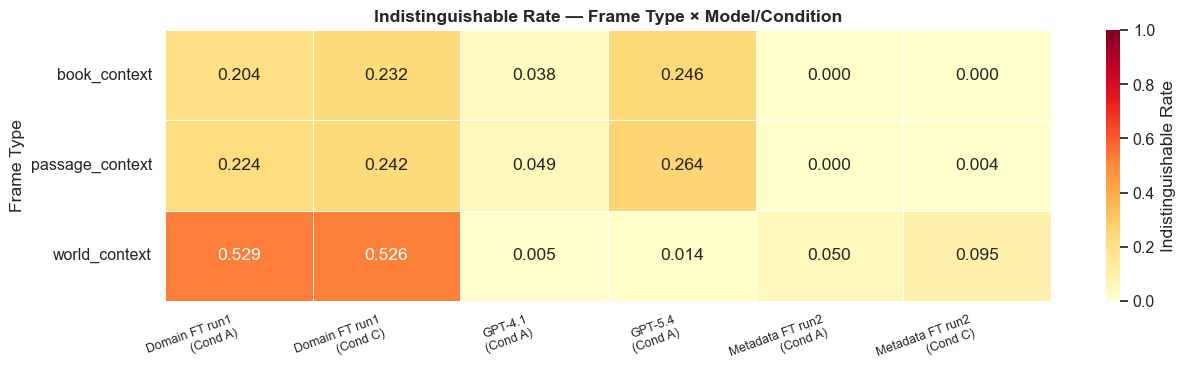

In [14]:
# ── Heatmap: accuracy by frame_type × model/condition ────────────────────────
heat_ft = ft_acc.copy()
heat_ft['label'] = [label(r['model'], r['condition']) for _, r in heat_ft.iterrows()]
heat_ft_piv = heat_ft.pivot_table(index='frame_type', columns='label', values='accuracy')

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(heat_ft_piv, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=0, vmax=1,
            cbar_kws={'label': 'Indistinguishable Rate'})
ax.set_title('Indistinguishable Rate — Frame Type × Model/Condition', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Frame Type')
plt.xticks(rotation=20, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

---
## 4 — Reasoning Type Deep Dive
Questions grouped by cognitive operation required: inference, knowledge recall, phrase/sentence cloze, constrained generation, character modeling, abstention, topic sentence, etc.

In [15]:
# ── Accuracy by reasoning_type ────────────────────────────────────────────────
rt_acc = (
    df_q.groupby(['model','condition','group','reasoning_type'])['score_q']
    .agg(accuracy='mean', n='count')
    .reset_index()
)

rt_table = rt_acc.pivot_table(
    index=['model','condition'], columns='reasoning_type', values='accuracy'
).round(4)
print('=== Indistinguishable Rate by Reasoning Type ===')
display(rt_table.T.style
    .format('{:.4f}', na_rep='—')
    .background_gradient(cmap='RdYlGn', axis=None)
)

=== Indistinguishable Rate by Reasoning Type ===


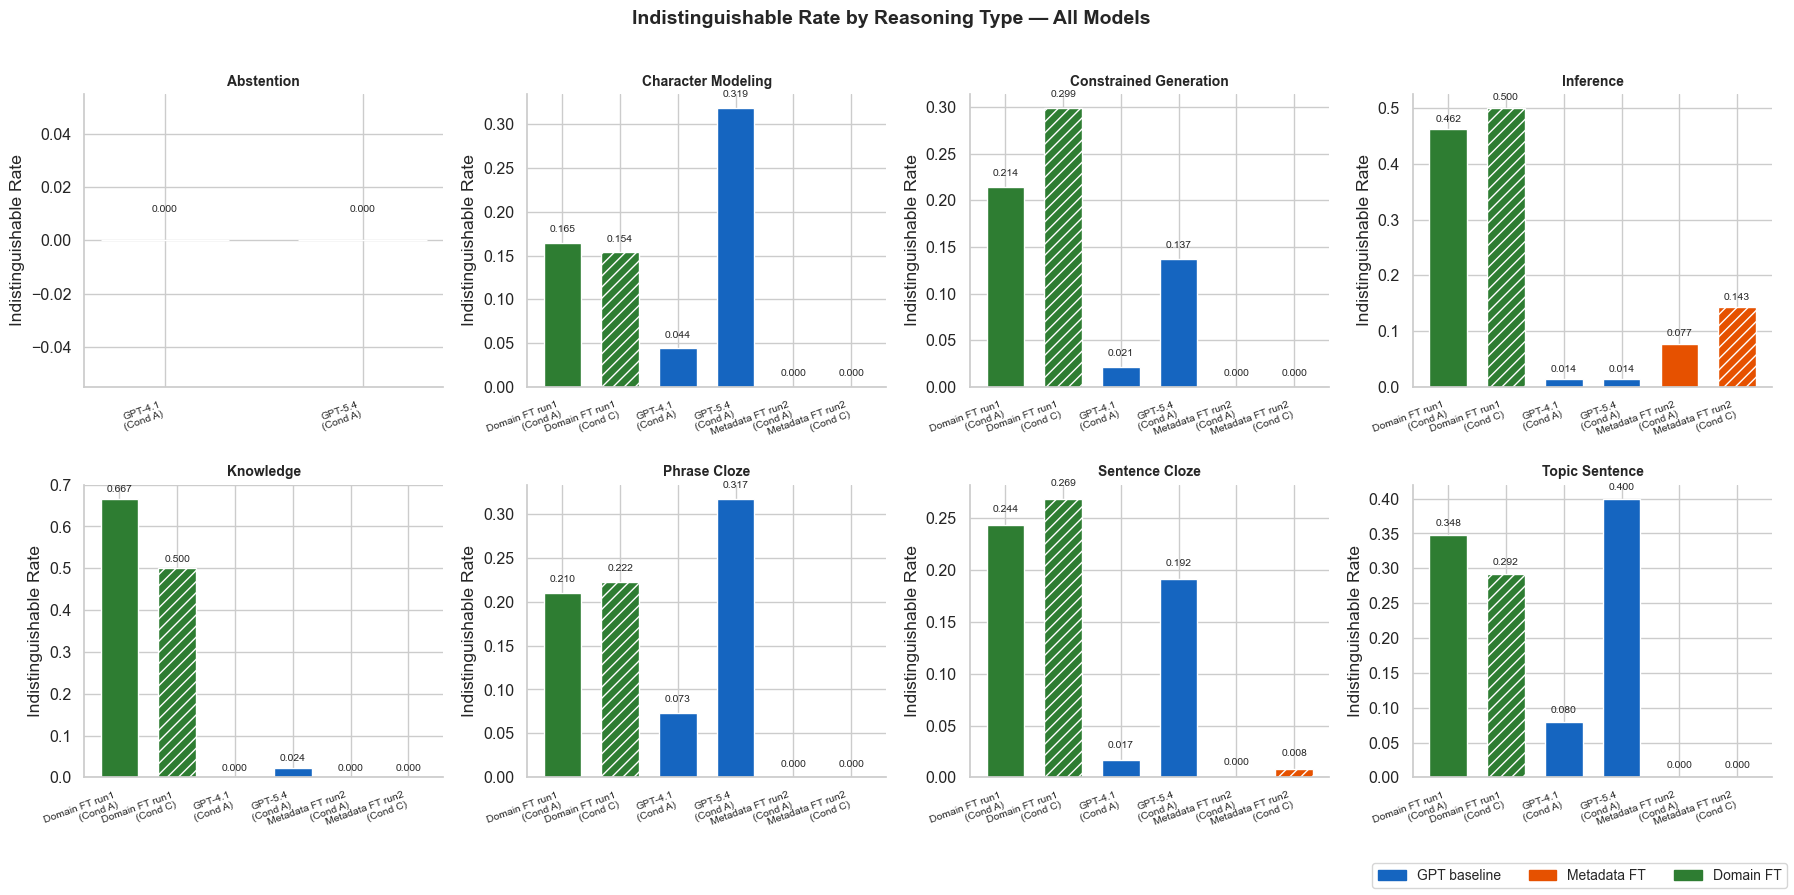

In [16]:
# ── Large grouped bar: one subplot per reasoning type ────────────────────────
reason_types = sorted(rt_acc['reasoning_type'].unique())
ncols = 4
nrows = (len(reason_types) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4.5), sharey=False)
axes_flat = axes.flatten() if nrows > 1 else list(axes)

for ax, rt in zip(axes_flat, reason_types):
    sub = rt_acc[rt_acc['reasoning_type'] == rt].copy()
    sub['label'] = [label(r['model'], r['condition']) for _, r in sub.iterrows()]
    x = np.arange(len(sub))
    colors  = [GROUP_COLORS[r['group']]    for _, r in sub.iterrows()]
    hatches = [COND_HATCH[r['condition']]  for _, r in sub.iterrows()]
    bars = ax.bar(x, sub['accuracy'], color=colors, edgecolor='white', width=0.65)
    for bar, h in zip(bars, hatches):
        bar.set_hatch(h)
    for bar, v in zip(bars, sub['accuracy']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)
    ax.set_xticks(x)
    ax.set_xticklabels(sub['label'], rotation=20, ha='right', fontsize=7.5)
    ax.set_title(rt.replace('_',' ').title(), fontweight='bold', fontsize=10)
    ax.set_ylabel('Indistinguishable Rate')
    ax.spines[['top','right']].set_visible(False)

for ax in axes_flat[len(reason_types):]:
    ax.set_visible(False)

handles = [mpatches.Patch(color=c, label=g) for g, c in GROUP_COLORS.items()]
fig.legend(handles=handles, loc='lower right', ncol=3, fontsize=10)
plt.suptitle('Indistinguishable Rate by Reasoning Type — All Models', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.04, 1, 0.97])
plt.show()

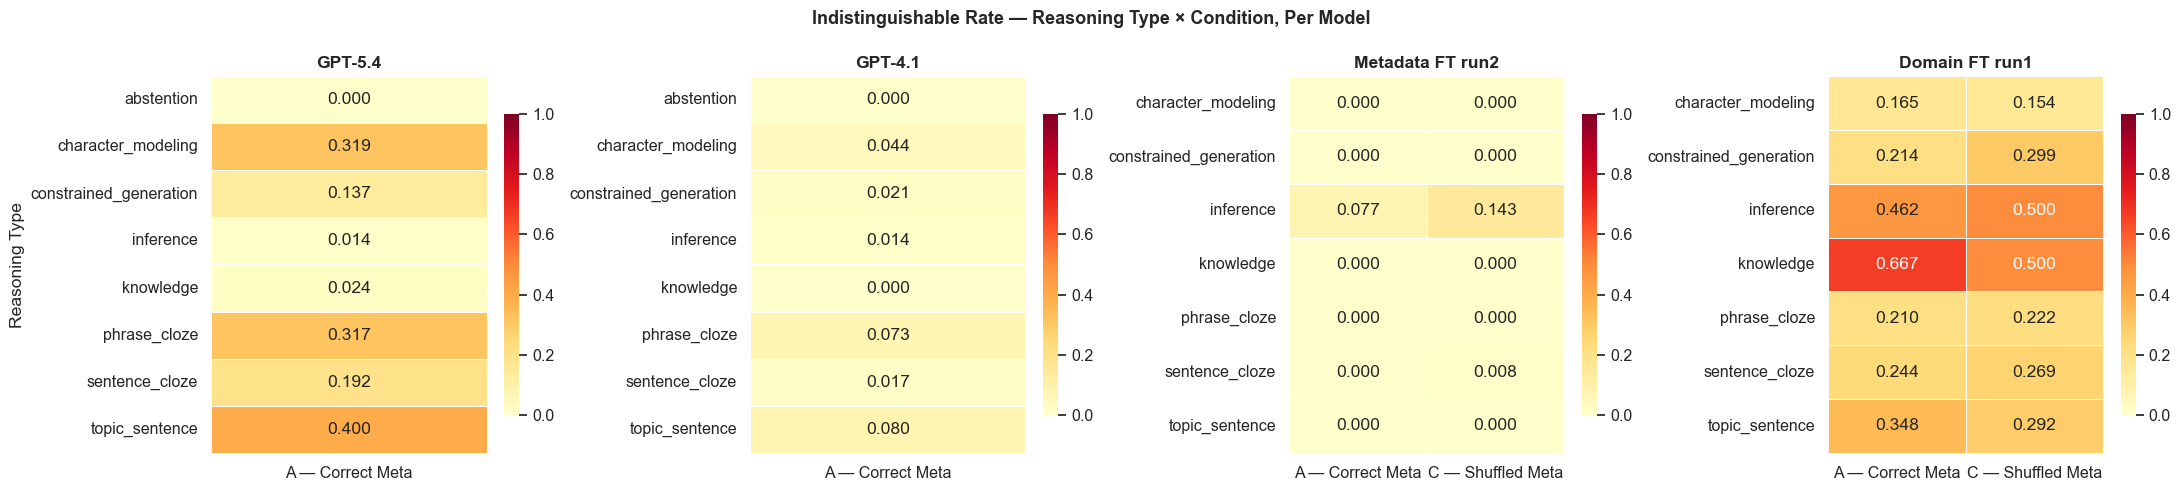

In [17]:
# ── Per-model heatmap: reasoning_type × condition ────────────────────────────
models_present = [m for m in MODEL_ORDER if m in rt_acc['model'].unique()]
fig, axes = plt.subplots(1, len(models_present), figsize=(5.5*len(models_present), 5))
if len(models_present) == 1:
    axes = [axes]

for ax, model in zip(axes, models_present):
    sub  = rt_acc[rt_acc['model'] == model]
    heat = sub.pivot_table(index='reasoning_type', columns='condition', values='accuracy')
    heat.columns = [COND_LABELS.get(c, c) for c in heat.columns]
    sns.heatmap(heat, annot=True, fmt='.3f', cmap='YlOrRd',
                linewidths=0.5, ax=ax, vmin=0, vmax=1,
                cbar_kws={'shrink': 0.8})
    ax.set_title(model, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Reasoning Type' if ax == axes[0] else '')

plt.suptitle('Indistinguishable Rate — Reasoning Type × Condition, Per Model',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5 — Metadata Impact Analysis

### 5a — condA vs condC overall

A positive A−C delta means the model performs better with **correct** metadata.
A negative delta means shuffled metadata is actually helpful (model uses it as a stylistic anchor).

In [18]:
# ── Delta A-C: overall ────────────────────────────────────────────────────────
def delta_ac(pivot_df):
    if 'A' not in pivot_df.columns or 'C' not in pivot_df.columns:
        return pd.Series(dtype=float)
    return pivot_df['A'] - pivot_df['C']

pivot_oa_models = df_overall.pivot_table(
    index=['model','group'], columns='condition',
    values='estimated_overall_accuracy'
).dropna(subset=['A','C'] if 'A' in df_overall['condition'].values else ['A'])

print('=== Metadata Sensitivity: condA − condC (Estimated Overall Accuracy) ===')
for (model, group), row in pivot_oa_models.iterrows():
    if 'A' in row.index and 'C' in row.index and not pd.isna(row.get('C')):
        delta = row['A'] - row['C']
        tag = 'correct meta helps' if delta > 0.01 else ('shuffled meta helps' if delta < -0.01 else 'neutral')
        print(f'  {model} ({group}):  A={row["A"]:.4f}  C={row.get("C",float("nan")):.4f}  Δ={delta:+.4f}  [{tag}]')
    elif 'A' in row.index:
        print(f'  {model} ({group}):  A={row["A"]:.4f}  C=—  (no condC run)')

=== Metadata Sensitivity: condA − condC (Estimated Overall Accuracy) ===
  Domain FT run1 (Domain FT):  A=0.3221  C=0.3557  Δ=-0.0336  [shuffled meta helps]
  Metadata FT run2 (Metadata FT):  A=0.0028  C=0.0084  Δ=-0.0056  [neutral]


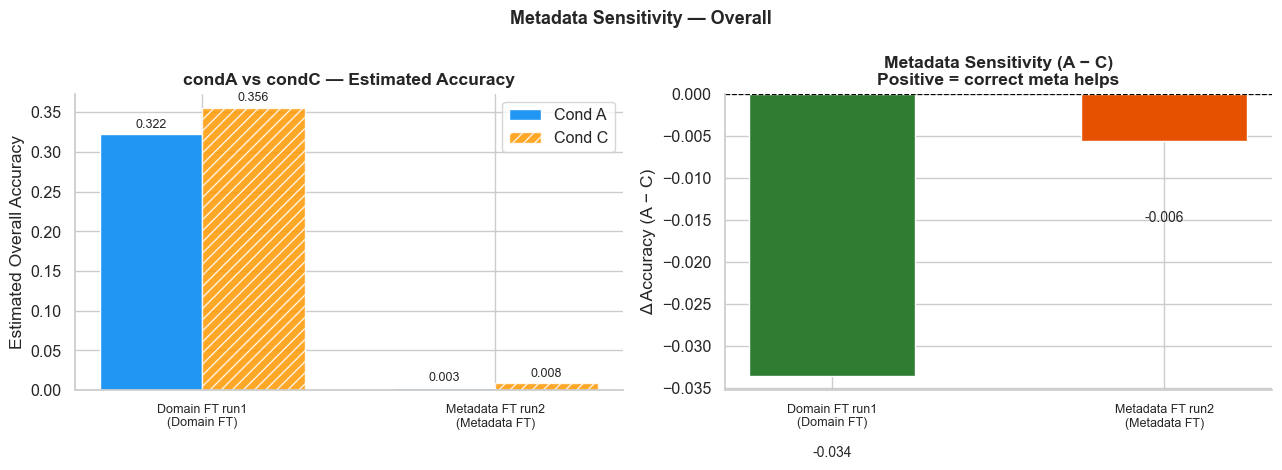

In [19]:
# ── Delta A-C bar chart (overall) ─────────────────────────────────────────────
paired = df_overall[df_overall['condition'].isin(['A','C'])].copy()
pivot_pairs = paired.pivot_table(
    index=['model','group'], columns='condition',
    values='estimated_overall_accuracy'
).dropna()

if not pivot_pairs.empty:
    delta_overall = (pivot_pairs['A'] - pivot_pairs['C']).reset_index()
    delta_overall.columns = ['model','group','delta']

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Left: side-by-side condA vs condC
    ax = axes[0]
    x = np.arange(len(pivot_pairs))
    w = 0.35
    bar_A = ax.bar(x - w/2, pivot_pairs['A'], width=w, color='#2196F3', label='Cond A', edgecolor='white')
    bar_C = ax.bar(x + w/2, pivot_pairs['C'], width=w, color='#FF9800', label='Cond C', edgecolor='white', hatch='///', alpha=0.85)
    for bar in list(bar_A) + list(bar_C):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{r["model"]}\n({r["group"]})' for _, r in delta_overall.iterrows()], fontsize=9)
    ax.set_ylabel('Estimated Overall Accuracy')
    ax.set_title('condA vs condC — Estimated Accuracy', fontweight='bold')
    ax.legend()
    ax.spines[['top','right']].set_visible(False)

    # Right: delta A-C
    ax = axes[1]
    colors_d = [GROUP_COLORS[r['group']] for _, r in delta_overall.iterrows()]
    bars = ax.bar(x, delta_overall['delta'], color=colors_d, edgecolor='white', width=0.5)
    for bar, v in zip(bars, delta_overall['delta']):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.003 if v >= 0 else -0.01),
                f'{v:+.3f}', ha='center', va='bottom', fontsize=10)
    ax.axhline(0, color='black', linewidth=0.9, linestyle='--')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{r["model"]}\n({r["group"]})' for _, r in delta_overall.iterrows()], fontsize=9)
    ax.set_ylabel('Δ Accuracy (A − C)')
    ax.set_title('Metadata Sensitivity (A − C)\nPositive = correct meta helps', fontweight='bold')
    ax.spines[['top','right']].set_visible(False)

    plt.suptitle('Metadata Sensitivity — Overall', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 5b — Metadata sensitivity by Frame Type

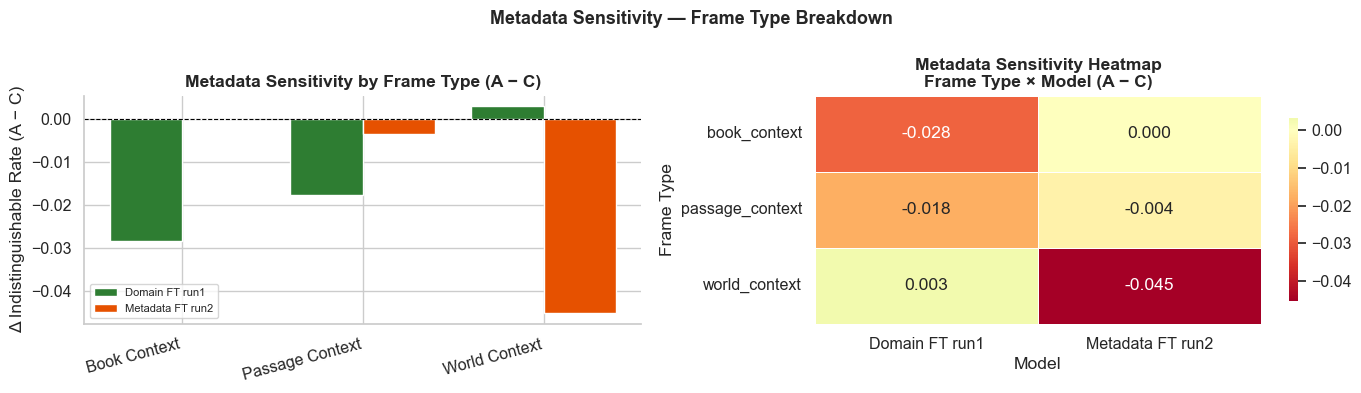

In [20]:
# ── Delta A-C by frame_type ───────────────────────────────────────────────────
ft_pivot = ft_acc.pivot_table(
    index=['model','group','frame_type'], columns='condition', values='accuracy'
).reset_index()

ft_paired = ft_pivot.dropna(subset=['A'] if 'A' in ft_pivot.columns else []).copy()
if 'C' in ft_paired.columns:
    ft_paired['delta_AC'] = ft_paired['A'] - ft_paired['C']
    ft_paired = ft_paired.dropna(subset=['delta_AC'])

    delta_ft = ft_paired.pivot_table(index='frame_type', columns='model', values='delta_AC')

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Grouped bar
    ax = axes[0]
    fts   = delta_ft.index.tolist()
    mods  = delta_ft.columns.tolist()
    x     = np.arange(len(fts))
    w     = 0.8 / max(len(mods), 1)
    for i, mod in enumerate(mods):
        ax.bar(x + i*w - (len(mods)-1)*w/2, delta_ft[mod],
               width=w, color=MODEL_COLORS.get(mod,'grey'), label=mod, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xticks(x)
    ax.set_xticklabels([f.replace('_',' ').title() for f in fts], rotation=15, ha='right')
    ax.set_ylabel('Δ Indistinguishable Rate (A − C)')
    ax.set_title('Metadata Sensitivity by Frame Type (A − C)', fontweight='bold')
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)

    # Heatmap
    ax = axes[1]
    sns.heatmap(delta_ft, annot=True, fmt='.3f', center=0,
                cmap='RdYlGn', linewidths=0.5, ax=ax, cbar_kws={'shrink':0.8})
    ax.set_title('Metadata Sensitivity Heatmap\nFrame Type × Model (A − C)', fontweight='bold')
    ax.set_xlabel('Model')
    ax.set_ylabel('Frame Type')

    plt.suptitle('Metadata Sensitivity — Frame Type Breakdown', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('condC data not available for frame-type delta analysis.')

### 5c — Metadata sensitivity by Reasoning Type

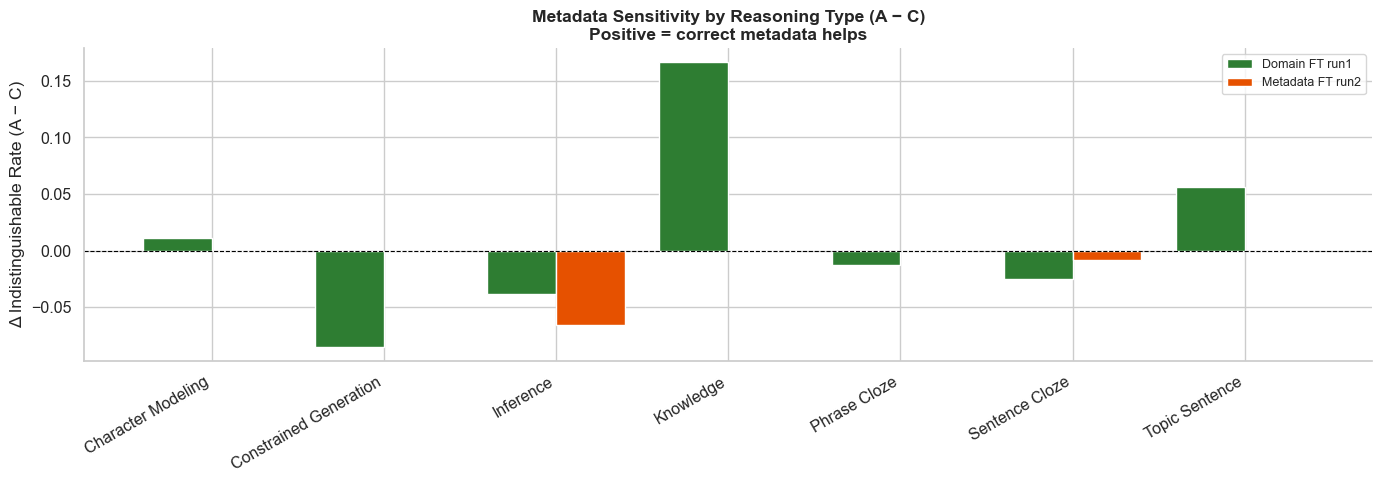

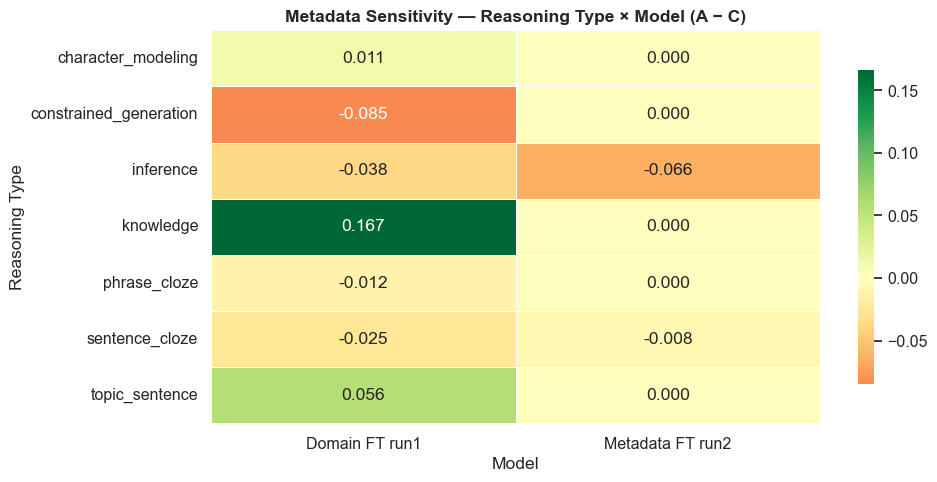

In [21]:
# ── Delta A-C by reasoning_type ───────────────────────────────────────────────
rt_pivot = rt_acc.pivot_table(
    index=['model','group','reasoning_type'], columns='condition', values='accuracy'
).reset_index()

if 'C' in rt_pivot.columns:
    rt_pivot['delta_AC'] = rt_pivot['A'] - rt_pivot['C']
    rt_paired = rt_pivot.dropna(subset=['delta_AC'])
    delta_rt   = rt_paired.pivot_table(index='reasoning_type', columns='model', values='delta_AC')

    # Grouped bar
    fig, ax = plt.subplots(figsize=(14, 5))
    rts  = delta_rt.index.tolist()
    mods = delta_rt.columns.tolist()
    x    = np.arange(len(rts))
    w    = 0.8 / max(len(mods), 1)
    for i, mod in enumerate(mods):
        ax.bar(x + i*w - (len(mods)-1)*w/2, delta_rt[mod],
               width=w, color=MODEL_COLORS.get(mod,'grey'), label=mod, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xticks(x)
    ax.set_xticklabels([r.replace('_',' ').title() for r in rts], rotation=30, ha='right')
    ax.set_ylabel('Δ Indistinguishable Rate (A − C)')
    ax.set_title('Metadata Sensitivity by Reasoning Type (A − C)\nPositive = correct metadata helps', fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.show()

    # Heatmap
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(delta_rt, annot=True, fmt='.3f', center=0,
                cmap='RdYlGn', linewidths=0.5, ax=ax, cbar_kws={'shrink':0.8})
    ax.set_title('Metadata Sensitivity — Reasoning Type × Model (A − C)', fontweight='bold')
    ax.set_xlabel('Model')
    ax.set_ylabel('Reasoning Type')
    plt.tight_layout()
    plt.show()
else:
    print('condC data not available for reasoning-type delta analysis.')

### 5d — Scatter: condA accuracy vs condC accuracy per reasoning type

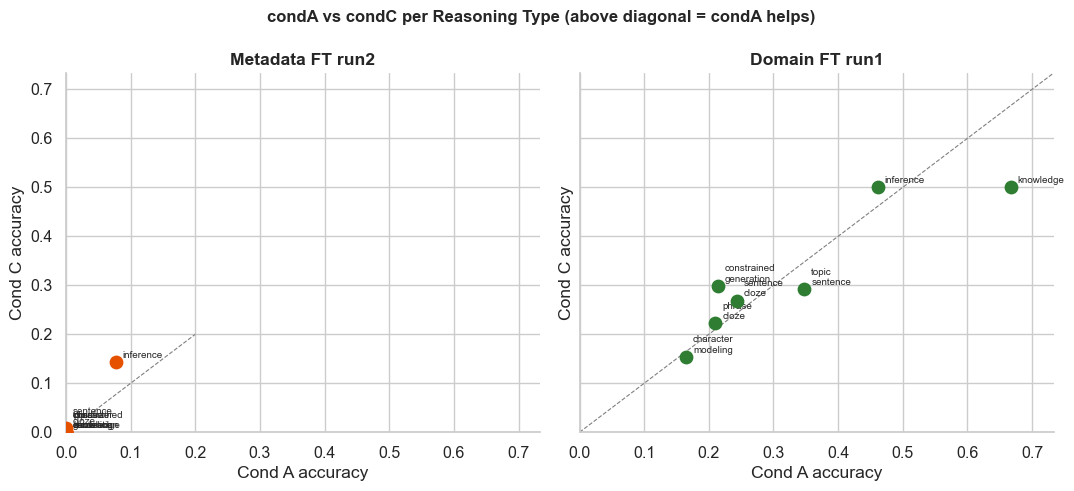

In [22]:
# ── Scatter per model: condA vs condC per reasoning type ─────────────────────
if 'C' in rt_pivot.columns:
    ft_models = [m for m in MODEL_ORDER if m in rt_paired['model'].unique()]
    fig, axes = plt.subplots(1, len(ft_models), figsize=(5.5*len(ft_models), 5),
                              sharex=True, sharey=True)
    if len(ft_models) == 1:
        axes = [axes]

    for ax, model in zip(axes, ft_models):
        sub = rt_paired[rt_paired['model'] == model]
        ax.scatter(sub['A'], sub['C'], s=80,
                   color=MODEL_COLORS.get(model,'grey'), zorder=5)
        for _, row in sub.iterrows():
            ax.annotate(row['reasoning_type'].replace('_','\n'),
                        (row['A'], row['C']),
                        textcoords='offset points', xytext=(5,3), fontsize=7, ha='left')
        lims = [0, max(sub[['A','C']].max().max() * 1.1, 0.2)]
        ax.plot(lims, lims, color='grey', linewidth=0.8, linestyle='--')  # diagonal
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_xlabel('Cond A accuracy')
        ax.set_ylabel('Cond C accuracy')
        ax.set_title(model, fontweight='bold')
        ax.spines[['top','right']].set_visible(False)

    plt.suptitle('condA vs condC per Reasoning Type (above diagonal = condA helps)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 6 — Model Comparison
### 6a — condA: all models across reasoning types

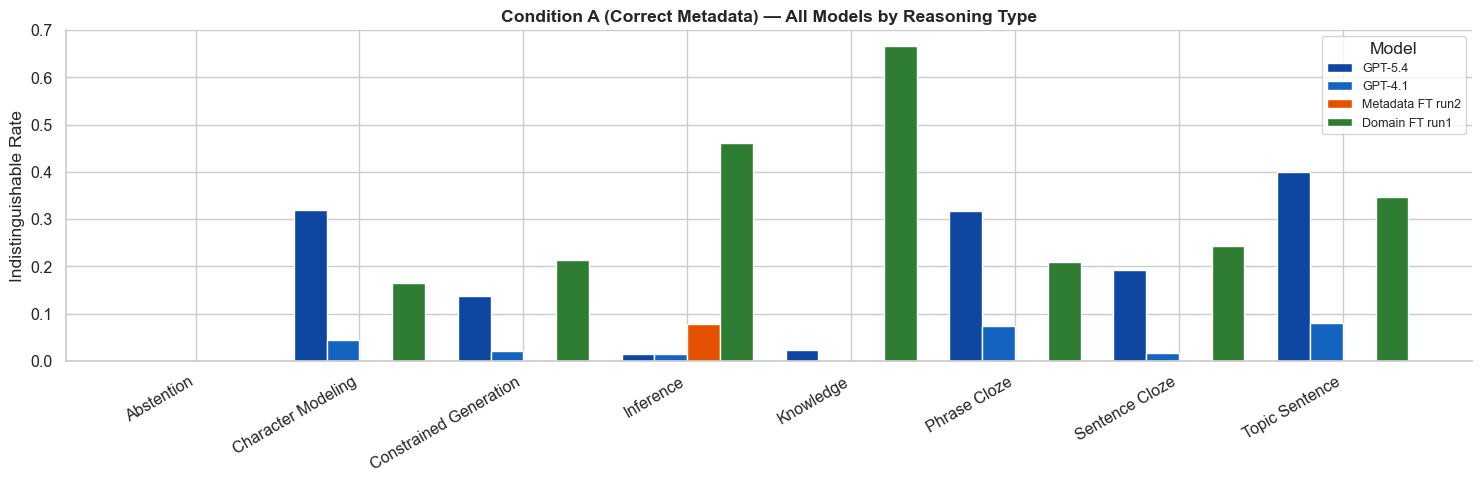

In [23]:
# ── condA: all models by reasoning type ──────────────────────────────────────
condA_rt = rt_acc[rt_acc['condition'] == 'A'].copy()
pivot_condA_rt = condA_rt.pivot_table(index='reasoning_type', columns='model', values='accuracy')

fig, ax = plt.subplots(figsize=(15, 5))
rts  = pivot_condA_rt.index.tolist()
mods = [m for m in MODEL_ORDER if m in pivot_condA_rt.columns]
x    = np.arange(len(rts))
w    = 0.8 / max(len(mods), 1)

for i, mod in enumerate(mods):
    ax.bar(x + i*w - (len(mods)-1)*w/2, pivot_condA_rt.get(mod, pd.Series(dtype=float)),
           width=w, color=MODEL_COLORS.get(mod,'grey'), label=mod, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([r.replace('_',' ').title() for r in rts], rotation=30, ha='right')
ax.set_ylabel('Indistinguishable Rate')
ax.set_title('Condition A (Correct Metadata) — All Models by Reasoning Type', fontweight='bold')
ax.legend(title='Model', fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

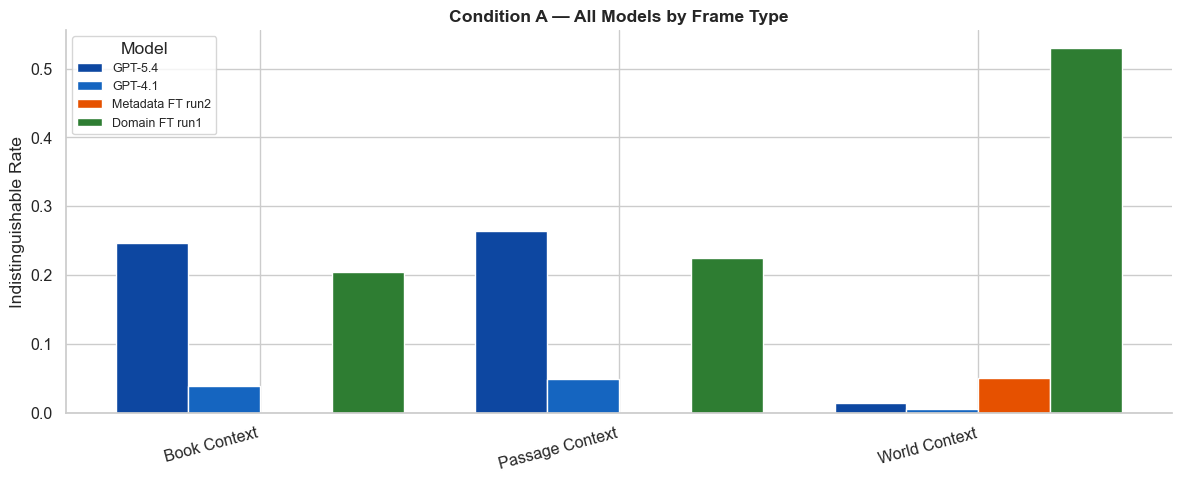

In [24]:
# ── condA: all models by frame type ──────────────────────────────────────────
condA_ft = ft_acc[ft_acc['condition'] == 'A'].copy()
pivot_condA_ft = condA_ft.pivot_table(index='frame_type', columns='model', values='accuracy')

fig, ax = plt.subplots(figsize=(12, 5))
fts  = pivot_condA_ft.index.tolist()
mods = [m for m in MODEL_ORDER if m in pivot_condA_ft.columns]
x    = np.arange(len(fts))
w    = 0.8 / max(len(mods), 1)

for i, mod in enumerate(mods):
    ax.bar(x + i*w - (len(mods)-1)*w/2, pivot_condA_ft.get(mod, pd.Series(dtype=float)),
           width=w, color=MODEL_COLORS.get(mod,'grey'), label=mod, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([f.replace('_',' ').title() for f in fts], rotation=15, ha='right')
ax.set_ylabel('Indistinguishable Rate')
ax.set_title('Condition A — All Models by Frame Type', fontweight='bold')
ax.legend(title='Model', fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

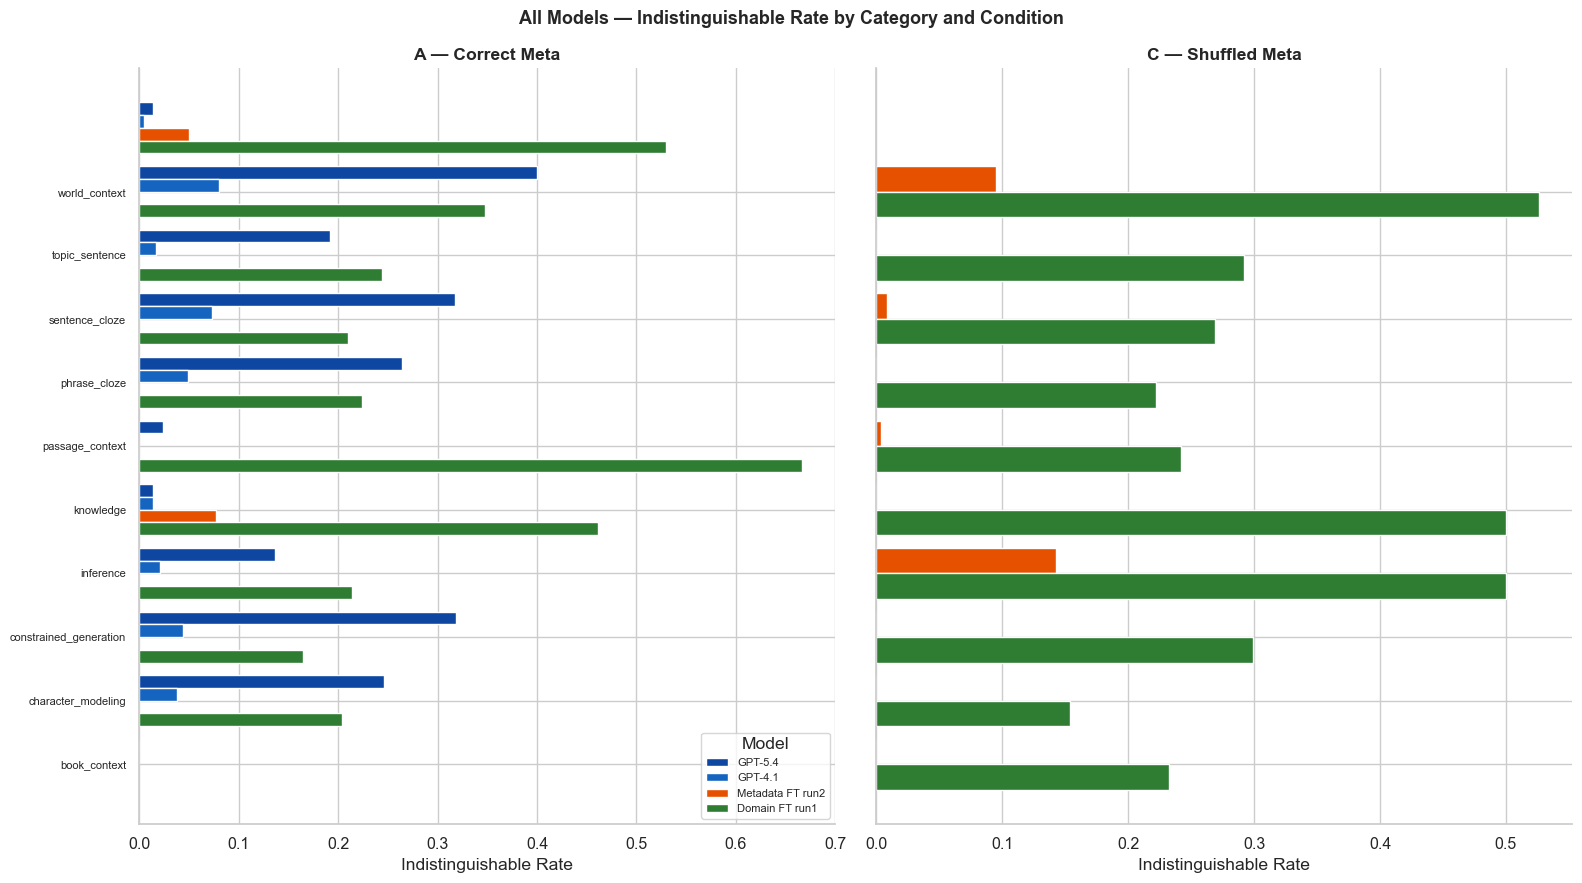

In [25]:
# ── Horizontal bar: all models × categories, per condition ────────────────────
all_acc = pd.concat([
    ft_acc.rename(columns={'frame_type': 'category'}).assign(breakdown='frame_type'),
    rt_acc.rename(columns={'reasoning_type': 'category'}).assign(breakdown='reasoning_type'),
])

conditions_avail = sorted(all_acc['condition'].unique())
fig, axes = plt.subplots(1, len(conditions_avail), figsize=(8*len(conditions_avail), 9), sharey=True)
if len(conditions_avail) == 1:
    axes = [axes]

for ax, cond in zip(axes, conditions_avail):
    sub = all_acc[all_acc['condition'] == cond]
    pivot = sub.pivot_table(index='category', columns='model', values='accuracy')
    y = np.arange(len(pivot))
    mods = [m for m in MODEL_ORDER if m in pivot.columns]
    h = 0.8 / max(len(mods), 1)
    for i, mod in enumerate(mods):
        ax.barh(y - i*h + (len(mods)-1)*h/2,
                pivot.get(mod, pd.Series(dtype=float)),
                height=h, color=MODEL_COLORS.get(mod,'grey'),
                label=mod, edgecolor='white')
    ax.set_yticks(y)
    ax.set_yticklabels(pivot.index, fontsize=8)
    ax.set_title(COND_LABELS.get(cond, cond), fontweight='bold')
    ax.set_xlabel('Indistinguishable Rate')
    ax.spines[['top','right']].set_visible(False)

axes[0].legend(title='Model', loc='lower right', fontsize=8)
plt.suptitle('All Models — Indistinguishable Rate by Category and Condition',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7 — Full Metrics Heatmap

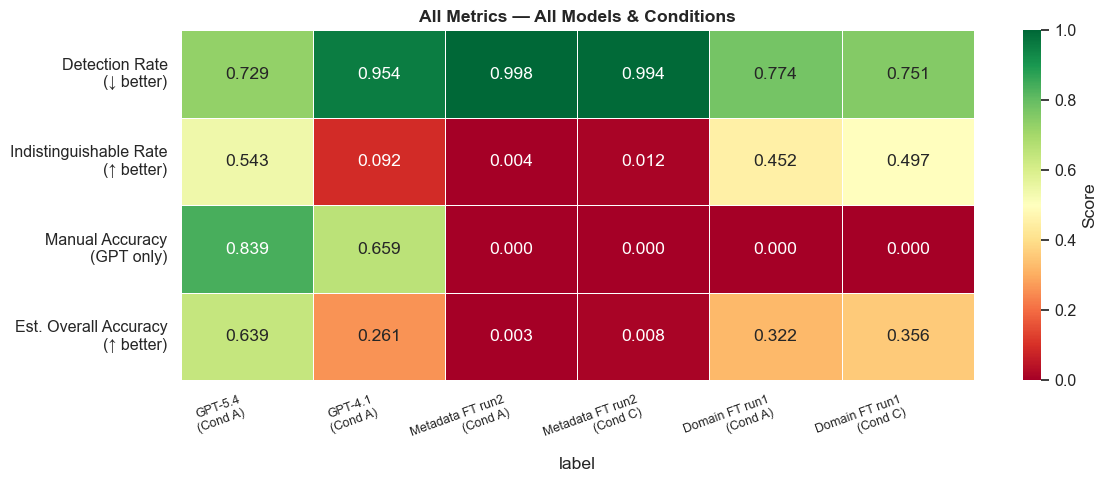

In [26]:
# ── All 4 aggregate metrics in one heatmap ───────────────────────────────────
df_h = df_overall.copy()
df_h['label'] = [label(r['model'], r['condition']) for _, r in df_h.iterrows()]
df_h = df_h.set_index('label')

heat_metrics = [
    ('detection_rate',             'Detection Rate\n(↓ better)'),
    ('indistinguishable_rate',     'Indistinguishable Rate\n(↑ better)'),
    ('manual_accuracy',            'Manual Accuracy\n(GPT only)'),
    ('estimated_overall_accuracy', 'Est. Overall Accuracy\n(↑ better)'),
]

heat_data = df_h[[m for m, _ in heat_metrics]].rename(
    columns={m: lbl for m, lbl in heat_metrics}
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(heat_data.T, annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, vmin=0, vmax=1,
            cbar_kws={'label': 'Score'})
ax.set_title('All Metrics — All Models & Conditions', fontweight='bold')
plt.xticks(rotation=20, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

---
## 8 — Radar Chart
Indistinguishable rate per reasoning type, condA — each model as a polygon.

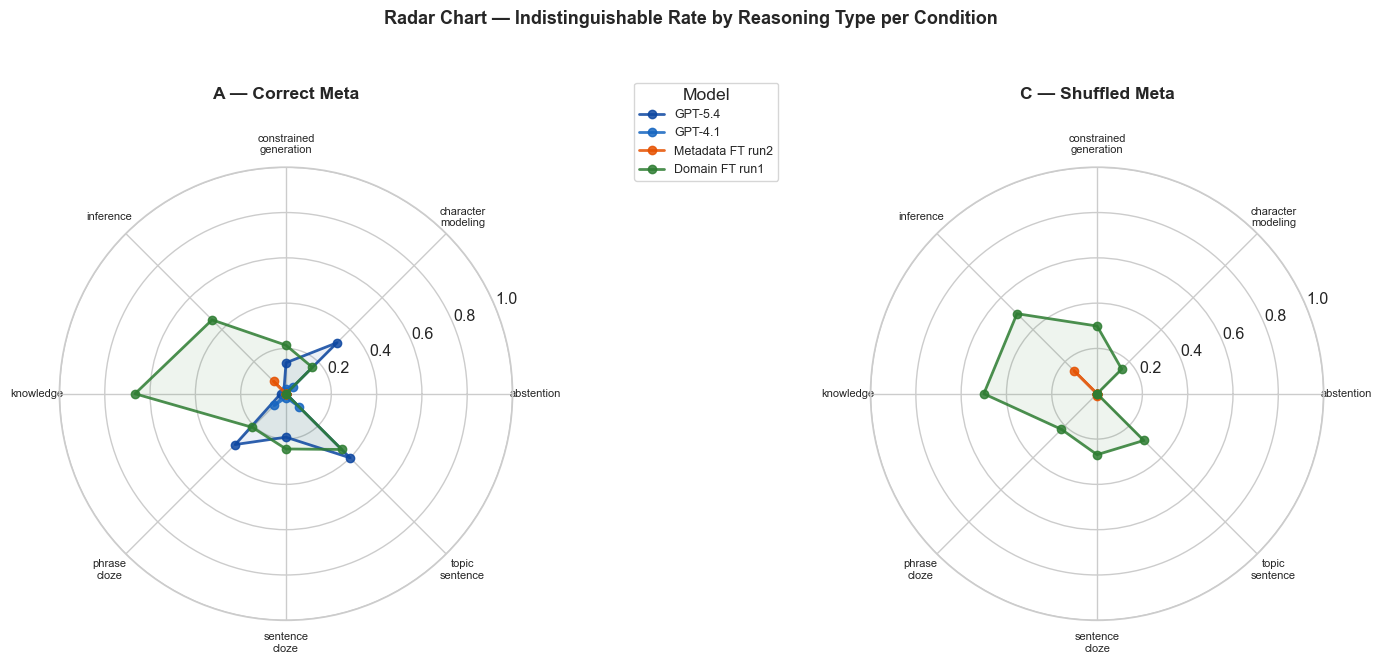

In [27]:
categories = sorted(rt_acc['reasoning_type'].unique())
N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

conditions_for_radar = sorted(all_acc['condition'].unique())
fig, axes = plt.subplots(1, len(conditions_for_radar), figsize=(7*len(conditions_for_radar), 7),
                          subplot_kw=dict(polar=True))
if len(conditions_for_radar) == 1:
    axes = [axes]

for ax, cond in zip(axes, conditions_for_radar):
    sub = rt_acc[rt_acc['condition'] == cond]
    for model in MODEL_ORDER:
        m = sub[sub['model'] == model].set_index('reasoning_type')['accuracy']
        if m.empty:
            continue
        vals = [m.get(c, 0) for c in categories] + [m.get(categories[0], 0)]
        ax.plot(angles, vals, 'o-', linewidth=2,
                color=MODEL_COLORS.get(model,'grey'), label=model, alpha=0.85)
        ax.fill(angles, vals, alpha=0.08, color=MODEL_COLORS.get(model,'grey'))

    ax.set_thetagrids(np.degrees(angles[:-1]),
                      [c.replace('_','\n') for c in categories], fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_title(COND_LABELS.get(cond, cond), fontweight='bold', pad=25)

axes[0].legend(title='Model', loc='upper right',
               bbox_to_anchor=(1.6, 1.2), fontsize=9)
plt.suptitle('Radar Chart — Indistinguishable Rate by Reasoning Type per Condition',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9 — Combined Summary Table & Key Findings

In [28]:
# ── Combined summary: reasoning_type accuracy condA & condC + delta ───────────
rows_out = []
for breakdown, grp_col, grp_df in [
    ('frame_type',     'frame_type',     ft_acc),
    ('reasoning_type', 'reasoning_type', rt_acc),
]:
    for model in MODEL_ORDER:
        sub = grp_df[grp_df['model'] == model]
        for grp in sub[grp_col].unique():
            g = sub[sub[grp_col] == grp]
            vals = g.set_index('condition')['accuracy'].to_dict()
            a = vals.get('A'); c = vals.get('C')
            rows_out.append({
                'Breakdown': breakdown,
                'Group':     grp,
                'Model':     model,
                'Acc_A':     a,
                'Acc_C':     c,
                'Delta_A-C': (a - c) if (a is not None and c is not None) else None,
            })

summary_full = pd.DataFrame(rows_out)
display(summary_full.style
    .format({'Acc_A': '{:.3f}', 'Acc_C': '{:.3f}', 'Delta_A-C': '{:+.3f}'}, na_rep='—')
    .background_gradient(cmap='RdYlGn', subset=['Acc_A','Acc_C'], axis=None)
    .background_gradient(cmap='PiYG',   subset=['Delta_A-C'],    axis=None)
    .set_caption('Acc = indistinguishable rate. Pink/Green = metadata effect direction.')
)

,Breakdown,Group,Model,Acc_A,Acc_C,Delta_A-C
0,frame_type,book_context,GPT-5.4,0.246,—,—
1,frame_type,passage_context,GPT-5.4,0.264,—,—
2,frame_type,world_context,GPT-5.4,0.014,—,—
3,frame_type,book_context,GPT-4.1,0.038,—,—
4,frame_type,passage_context,GPT-4.1,0.049,—,—
5,frame_type,world_context,GPT-4.1,0.005,—,—
6,frame_type,book_context,Metadata FT run2,0.000,0.000,+0.000
7,frame_type,passage_context,Metadata FT run2,0.000,0.004,-0.004
8,frame_type,world_context,Metadata FT run2,0.050,0.095,-0.045
9,frame_type,book_context,Domain FT run1,0.204,0.232,-0.028


In [29]:
# ── Key findings printout ─────────────────────────────────────────────────────
print('=' * 68)
print('KEY FINDINGS — FREE-GENERATION EVALUATION')
print('=' * 68)

print('\n1. ESTIMATED OVERALL ACCURACY (higher = better)')
for _, row in df_overall.sort_values('estimated_overall_accuracy', ascending=False).iterrows():
    print(f"   {row['model']:<22} Cond {row['condition']}  {row['estimated_overall_accuracy']:.4f}  [{row['group']}]")

print('\n2. DETECTION RATE (lower = better)')
for _, row in df_overall.sort_values('detection_rate').iterrows():
    print(f"   {row['model']:<22} Cond {row['condition']}  {row['detection_rate']:.4f}")

print('\n3. METADATA SENSITIVITY (condA − condC, estimated overall accuracy)')
if not pivot_pairs.empty:
    for (model, group), row in pivot_pairs.iterrows():
        delta = row['A'] - row['C']
        tag = 'correct meta helps' if delta > 0.01 else ('shuffled meta helps' if delta < -0.01 else 'neutral')
        print(f'   {model} ({group}):  A={row["A"]:.4f}  C={row["C"]:.4f}  Δ={delta:+.4f}  [{tag}]')
else:
    print('   (No model has both condA and condC runs)')

print('\n4. BEST REASONING TYPE (condA, per model, by indistinguishable rate)')
for model in MODEL_ORDER:
    sub = rt_acc[(rt_acc['model']==model) & (rt_acc['condition']=='A')]
    if sub.empty: continue
    best = sub.loc[sub['accuracy'].idxmax()]
    print(f'   {model:<22}: {best["reasoning_type"]:<28} {best["accuracy"]:.3f}')

print('\n5. WORST REASONING TYPE (condA, per model)')
for model in MODEL_ORDER:
    sub = rt_acc[(rt_acc['model']==model) & (rt_acc['condition']=='A')]
    if sub.empty: continue
    worst = sub.loc[sub['accuracy'].idxmin()]
    print(f'   {model:<22}: {worst["reasoning_type"]:<28} {worst["accuracy"]:.3f}')

print('\n6. NOTES')
print('   - Metadata FT run2 near-zero accuracy: training data had OCR number artifacts')
print('     causing model to output "168 168 168..." / "126. 127. 128..." repetitions')
print('   - Domain FT run1 (100 Gutenberg books) shows substantial recovery: ~0.32-0.36')
print('   - Domain FT condC > condA (Δ≈-0.034): model may anchor to historical style')
print('     rather than metadata, so shuffled metadata does not meaningfully hurt it')
print('   - GPT models use benchmark v0.1; Qwen models use v0.2 (different question sets)')
print('   - GPT per-question D/U breakdown underestimates true accuracy (no manual review')
print('     reflected per-question); use estimated_overall_accuracy for absolute comparisons')
print('=' * 68)

KEY FINDINGS — FREE-GENERATION EVALUATION

1. ESTIMATED OVERALL ACCURACY (higher = better)
   GPT-5.4                Cond A  0.6389  [GPT baseline]
   Domain FT run1         Cond C  0.3557  [Domain FT]
   Domain FT run1         Cond A  0.3221  [Domain FT]
   GPT-4.1                Cond A  0.2609  [GPT baseline]
   Metadata FT run2       Cond C  0.0084  [Metadata FT]
   Metadata FT run2       Cond A  0.0028  [Metadata FT]

2. DETECTION RATE (lower = better)
   GPT-5.4                Cond A  0.7286
   Domain FT run1         Cond C  0.7515
   Domain FT run1         Cond A  0.7741
   GPT-4.1                Cond A  0.9538
   Metadata FT run2       Cond C  0.9942
   Metadata FT run2       Cond A  0.9981

3. METADATA SENSITIVITY (condA − condC, estimated overall accuracy)
   Domain FT run1 (Domain FT):  A=0.3221  C=0.3557  Δ=-0.0336  [shuffled meta helps]
   Metadata FT run2 (Metadata FT):  A=0.0028  C=0.0084  Δ=-0.0056  [neutral]

4. BEST REASONING TYPE (condA, per model, by indistinguishabl